<a href="https://colab.research.google.com/github/Lalitmohan6376/Deep-Fake-Detection/blob/main/Deepfake_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("deepfake_detection_metadata_dataset.csv")

In [3]:
df.head(10)

,media_id,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,generation_method,label
0,1,Image,News,2,Yes,0.76,0.24,0.06,0.23,Facebook,NaN,Real
1,2,Video,News,3,Yes,0.01,0.82,0.62,0.98,Instagram,Diffusion,Fake
2,3,Video,Political Speech,3,No,0.20,0.66,0.23,0.77,News Website,GAN,Fake
3,4,Image,Social Media,4,Yes,0.81,0.19,0.68,0.29,YouTube,NaN,Real
4,5,Video,Interview,1,Yes,0.98,0.00,0.23,0.17,Twitter,NaN,Real
5,6,Audio,Interview,3,No,0.88,0.20,0.66,0.25,Instagram,NaN,Real
6,7,Video,News,3,No,0.40,0.52,0.40,0.42,Twitter,FaceSwap,Fake
7,8,Image,Entertainment,4,No,0.06,0.95,0.54,0.52,Instagram,VoiceClone,Fake
8,9,Audio,Entertainment,0,Yes,0.86,0.08,0.99,0.04,YouTube,NaN,Real
9,10,Audio,Social Media,0,Yes,0.57,0.40,0.07,0.82,Instagram,Diffusion,Fake


EDA(Exploratory Data Analysis)

In [4]:
# Missing values Analysis
def missing_values(data):
    return data.isnull().sum()

missing = missing_values(df)
print(missing)

media_id                          0
media_type                        0
content_category                  0
face_count                        0
audio_present                     0
lip_sync_score                    0
visual_artifacts_score            0
compression_level                 0
lighting_inconsistency_score      0
source_platform                   0
generation_method               501
label                             0
dtype: int64


In [5]:
def check_duplicate(df):
  print(df.duplicated().sum())

check_duplicate(df)

0


In [6]:
def column_separate(df):
  return df.select_dtypes(include=['object']).columns,df.select_dtypes(include=['int64','float64']).columns

cat_col, num_col = column_separate(df)
print(num_col)
print(cat_col)

Index(['media_id', 'face_count', 'lip_sync_score', 'visual_artifacts_score',
       'compression_level', 'lighting_inconsistency_score'],
      dtype='object')
Index(['media_type', 'content_category', 'audio_present', 'source_platform',
       'generation_method', 'label'],
      dtype='object')


In [7]:
def value_count(df, cols):
    for col in cols:
        print(f"\nColumn: {col}")
        print(df[col].value_counts())

value_count(df, num_col)


Column: media_id
media_id
1000    1
1       1
2       1
3       1
4       1
       ..
13      1
12      1
11      1
10      1
9       1
Name: count, Length: 1000, dtype: int64

Column: face_count
face_count
3    212
4    205
1    202
0    191
2    190
Name: count, dtype: int64

Column: lip_sync_score
lip_sync_score
0.82    27
0.83    24
0.85    24
0.72    23
0.86    21
        ..
0.62     3
0.03     3
0.38     3
0.12     2
0.11     1
Name: count, Length: 101, dtype: int64

Column: visual_artifacts_score
visual_artifacts_score
0.07    32
0.02    24
0.26    22
0.08    20
0.20    20
        ..
1.00     4
0.83     4
0.74     4
0.86     4
0.53     2
Name: count, Length: 92, dtype: int64

Column: compression_level
compression_level
0.63    18
0.78    18
0.11    18
0.65    17
0.90    16
        ..
0.25     4
0.55     4
1.00     4
0.76     3
0.14     3
Name: count, Length: 101, dtype: int64

Column: lighting_inconsistency_score
lighting_inconsistency_score
0.08    22
0.26    22
0.25    21
0.1

In [8]:
df['label'] = df['label'].str.strip().map({'Fake': 0, 'Real': 1})

df['audio_present'] = df['audio_present'].str.strip().map({'Yes': 1, 'No': 0})
df.head()

,media_id,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,generation_method,label
0,1,Image,News,2,1,0.76,0.24,0.06,0.23,Facebook,NaN,1
1,2,Video,News,3,1,0.01,0.82,0.62,0.98,Instagram,Diffusion,0
2,3,Video,Political Speech,3,0,0.20,0.66,0.23,0.77,News Website,GAN,0
3,4,Image,Social Media,4,1,0.81,0.19,0.68,0.29,YouTube,NaN,1
4,5,Video,Interview,1,1,0.98,0.00,0.23,0.17,Twitter,NaN,1


In [9]:
df[num_col].dtypes

,0
media_id,int64
face_count,int64
lip_sync_score,float64
visual_artifacts_score,float64
compression_level,float64
lighting_inconsistency_score,float64


In [10]:
# Target value Distrubution
def target_distribution(data):
  print(data['label'].value_counts())
  print(data['label'].value_counts(normalize=True)*100)

target_distribution(df)

label
1    501
0    499
Name: count, dtype: int64
label
1    50.1
0    49.9
Name: proportion, dtype: float64


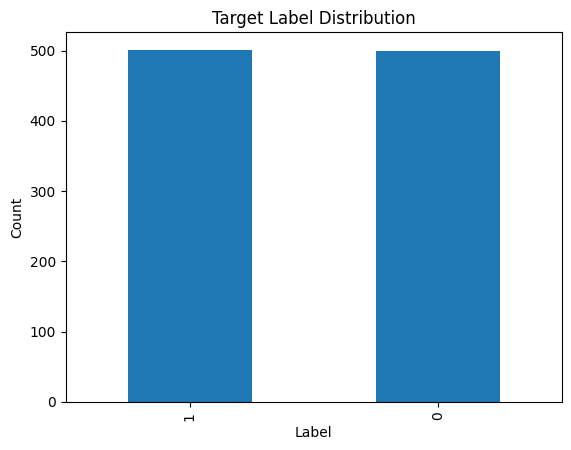

In [11]:
# Target Distribution Through Visulization
def plot_target_distribution(data):
    counts = data['label'].value_counts()

    plt.figure()
    counts.plot(kind='bar')

    plt.title("Target Label Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")

    plt.show()

plot_target_distribution(df)

In [12]:
# Skew Checking on numerical columns
def skew_check(num_col):
  return num_col.skew()

skew = skew_check(df[num_col])
skew

,0
media_id,0.000000
face_count,-0.037510
lip_sync_score,-0.475758
visual_artifacts_score,0.374613
compression_level,-0.102024
lighting_inconsistency_score,0.324938


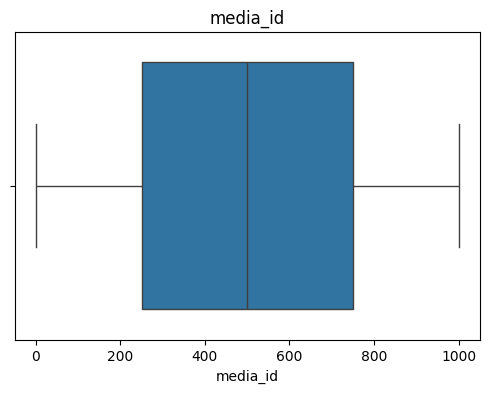

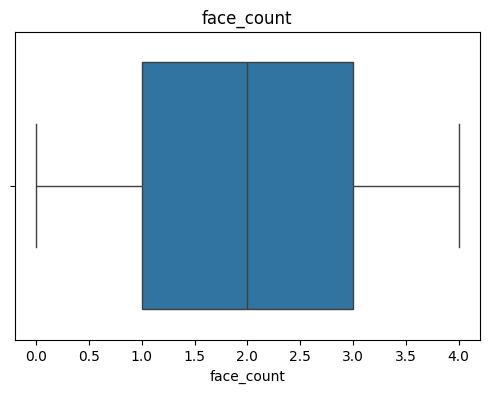

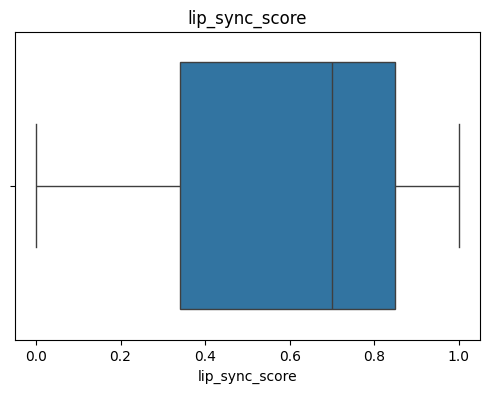

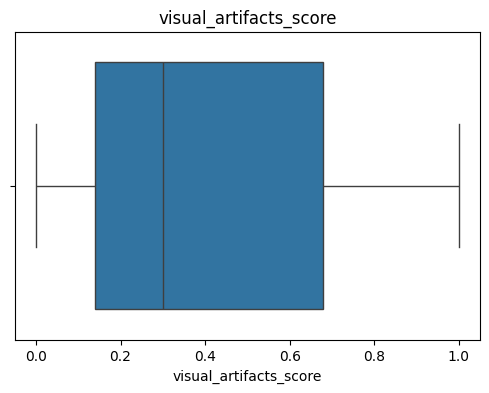

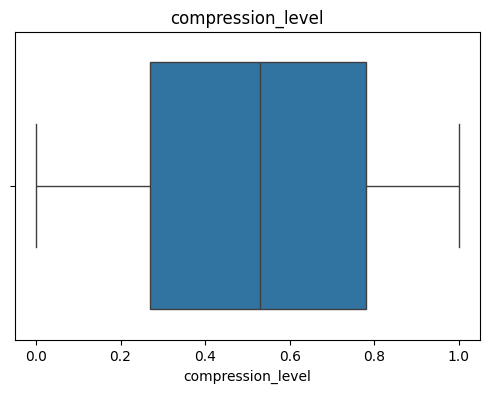

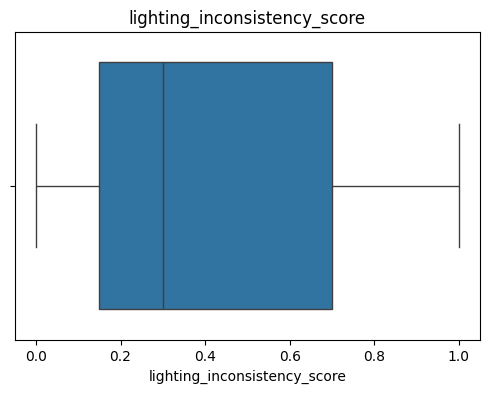

In [13]:
def outlier_detect(df):
  for col in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


outlier_detect(df)

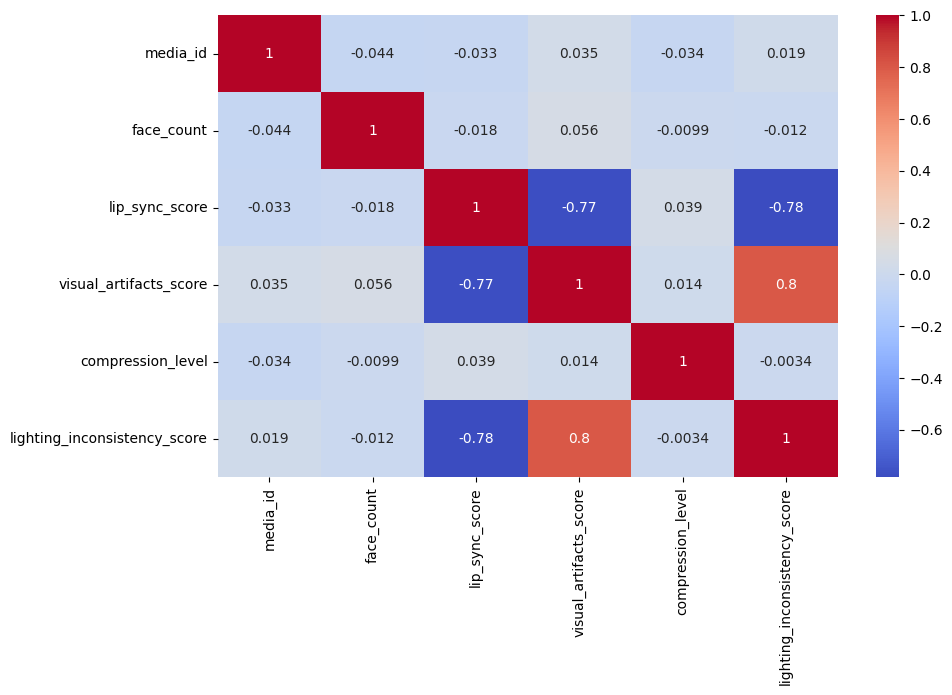

In [14]:

def heat_map(df):
    plt.figure(figsize=(10,6))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
    plt.show()


heat_map(df[num_col])



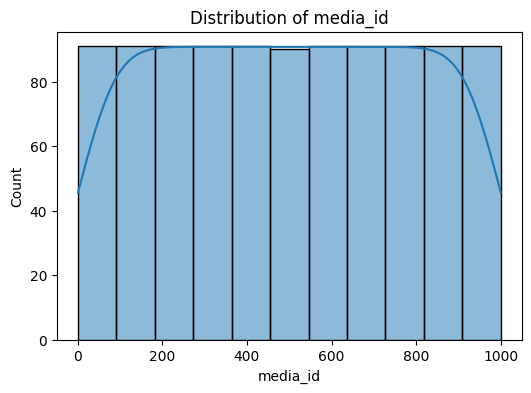

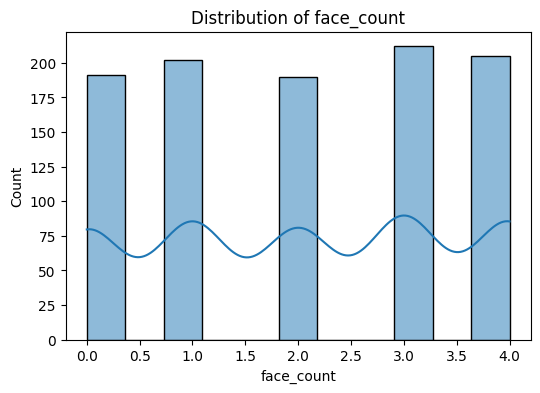

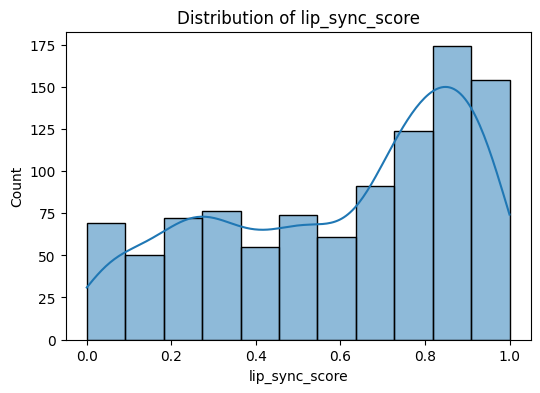

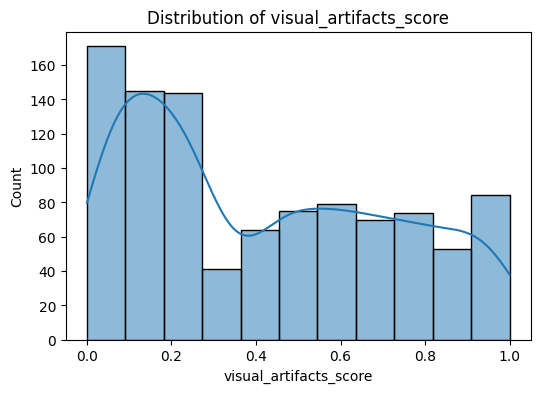

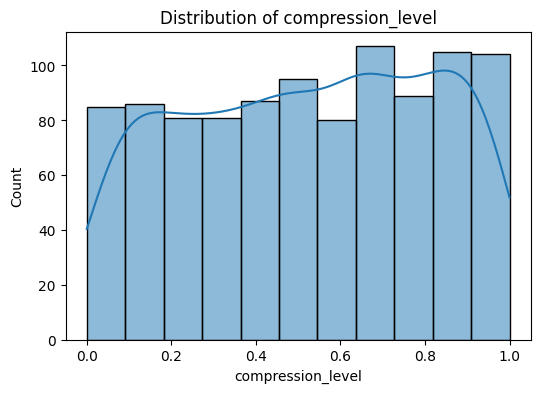

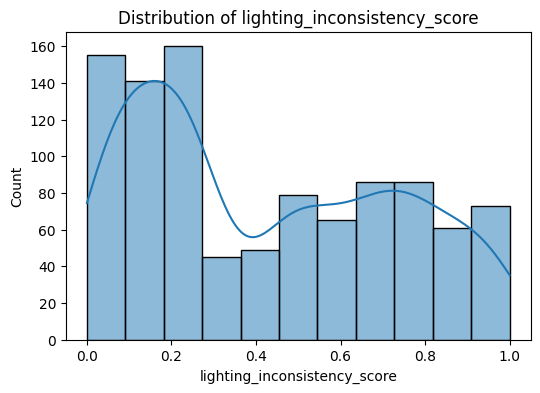

In [15]:

def skew_check(df):
    for col in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

skew_check(df[num_col])

In [16]:
df.dtypes

,0
media_id,int64
media_type,object
content_category,object
face_count,int64
audio_present,int64
lip_sync_score,float64
visual_artifacts_score,float64
compression_level,float64
lighting_inconsistency_score,float64
source_platform,object


In [17]:
def prepare_data(df, target_col):

    # Columns to drop
    cols_to_drop = [target_col, 'media_id', 'lip_sync_score', 'source_platform', 'lighting_inconsistency_score','generation_method','visual_artifacts_score']

    # Drop only those columns which exist
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

    y = df[target_col]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test


# Call function
X_train, X_test, y_train, y_test = prepare_data(df, 'label')

In [18]:
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns


In [19]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [20]:
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [21]:

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [22]:
model_pipeline = Pipeline([
    ("preproceesing",preprocessor),
    ("model", LogisticRegression()),
])

In [23]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preproceesing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['face_count', 'audio_present', 'compression_level'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['media_type', 'content_category'], dtype='object'))])),
                ('model', LogisticRegression())])

In [24]:
y_pred = model_pipeline.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.43


In [26]:
X_train.shape

(800, 5)